In [8]:
import sys
import os
sys.path.append('../') 

import plot_func
import isoquantViewer

In [11]:

data_dir = '.../PR211/results/isoquant_output/'  # path to IsoQuantOutput directory
referene_gtf = '.../Documents/ref/geneannotations.gff3' # path to reference gene annotation 
prefix = 'PR211' # Name of the project



This notebook provides examples on visualising IsoQuant outputs based on Basic Genomics RNA BaseCode data.  

In [12]:


output = isoquantViewer.isoquantViewer(
        output_directory=data_dir, 
        referene_gtf= referene_gtf,
        prefix = prefix)

# * Plots are automatically saved in the folder "./plot_output" if plot_output is not defined

/Users/kawai/miniconda3/envs/isoquant_viewer/lib/python3.10/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/kawai/miniconda3/envs/isoquant_viewer/lib/python3.10/site-packages/mudata/_core/mudata.py:963: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  warnings.warn(
/Users/kawai/miniconda3/envs/isoquant_viewer/lib/python3.10/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pu

Count matrices of the IsoQuant outputs are stored in a MuData object (HDF5-based) (https://mudata.readthedocs.io/en/latest/). As seen below, there are 4 stored matrices with their corresponding metadata (named 'modalities' in MuData).

The following 'modalities' are based on the IsoQuant transcript model: 
- gene
- isoform

The following 'modality' is based on the reference gene annotation: 
- reference_gene
- reference_isoform

Where the layer is named either 'count' or 'isoform', representing the count matrix of raw read counts or expression in TPM. 

### Visualization

#### Visualizing read assignment and counts

Function: 

- plot_pie_assignment

  Plot pie chart of read assignment (.read_assignments.tsv.gz; stored as .reads_assignment) from IsoQuant. "feature_to_plot" are: "assignment_type", "gene_assignment", "Classification"


- plot_count_bar

  A bar plot of counts for either specified genes or isoforms. If providing gene_list, plots stacked barplot of isoforms per gene. If providing isoform_list, plots a barplot of specified isoforms.

  Can either be from the raw count or TPM matrix using "layer", and based on the transcript model or the reference annotation (use_transcript_model=True or False, default is False). Default is plotting all available samples, but can be limited to specific sample using "sample_id" = [sample1, sample2, and etc.]
  

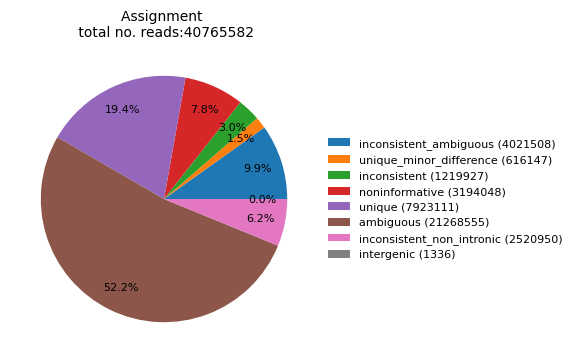

In [13]:
plot_func.plot_pie_assignment(output,feature_to_plot = 'assignment_type')

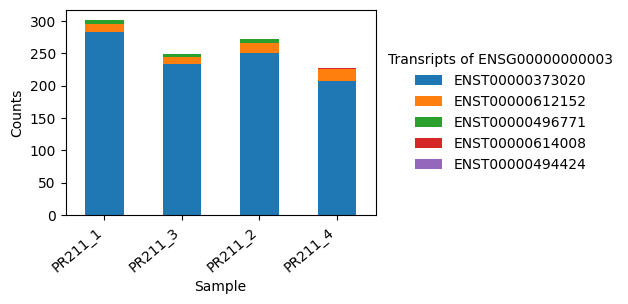

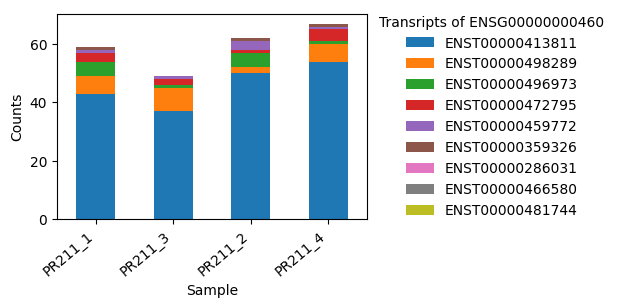

In [14]:
plot_func.plot_count_bar(output,layer = 'count',
               gene_list=['ENSG00000000003','ENSG00000000460'],use_transcript_model=False)

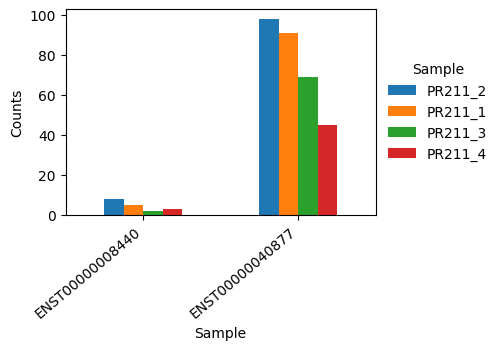

In [15]:
plot_func.plot_count_bar(output,'count',
                         isoform_list = ['ENST00000008440','ENST00000040877'],use_transcript_model=False)

#### Visualizing transcripts within a genomic region 

* plot_transcript_map

    Visualize transcript(s) for specified gene(s)/ensembl ID within the corresponding genomic region(s). Can be based on the transcript model or the reference genome. (Based on IsoQuant:plot_transcript_map) 

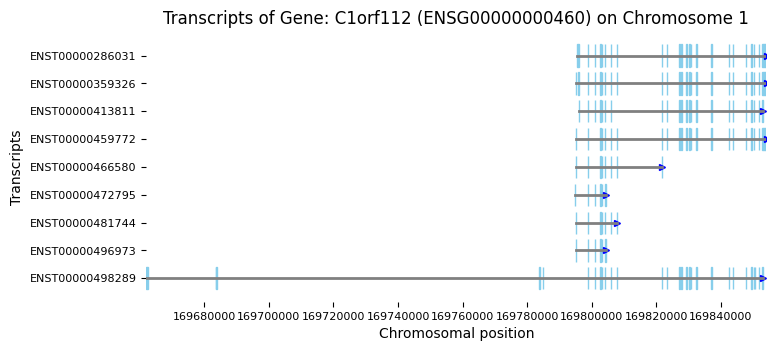

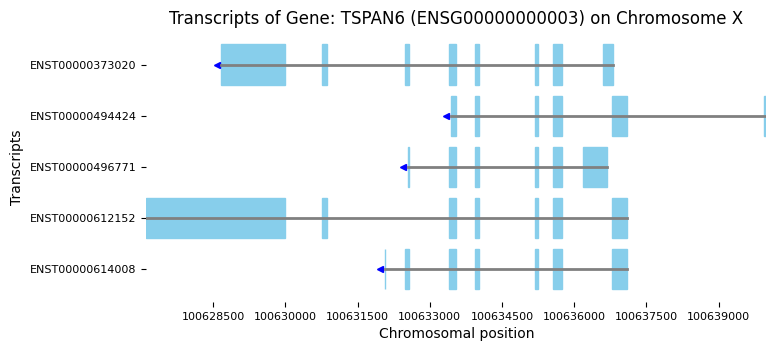

In [16]:
plot_func.plot_transcript_map(output,gene_names=['TSPAN6','C1orf112'],use_transcript_model=False)


- plot_genomic_region

  Visualize a genomic region defined by setting either:
  
    * region = 'X:100627109-100639991'
    * gene_name = 'TSPAN6'
    * or Ensembl_ID = 'ENSG00000000003'
  
  using pyGenomeTracks classes (https://pygenometracks.readthedocs.io/en/latest/).

  The default ordered tracks being plotted are ['ref','model','reads'],can be set using "plot_tracks".
    * 'ref': Reference GTF
    * 'model': IsoQuant transcript model GTF
    * 'reads': IsoQuant corrected alignment BED

  The default parameters for each track can be overwritten using tracks_params, by setting key-value pairs for any supported track property. (See the list of all available options at at https://pygenometracks.readthedocs.io/en/latest/content/all_tracks.html)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 135.47it/s]
DEBUG:pygenometracks.tracks.GenomeTrack:ylim 10.28,-0.08
DEBUG:pygenometracks.tracks.GenomeTrack:ylim (np.float64(10.28), np.float64(-0.08))
DEBUG:pygenometracks.tracks.GenomeTrack:ylim 3.38,-0.08
DEBUG:pygenometracks.tracks.GenomeTrack:ylim (np.float64(3.38), np.float64(-0.08))
DEBUG:pygenometracks.tracks.GenomeTrack:ylim 5962.679999999999,-0.08
DEBUG:pygenometracks.tracks.GenomeTrack:ylim (np.float64(5962.679999999999), np.float64(-0.08))


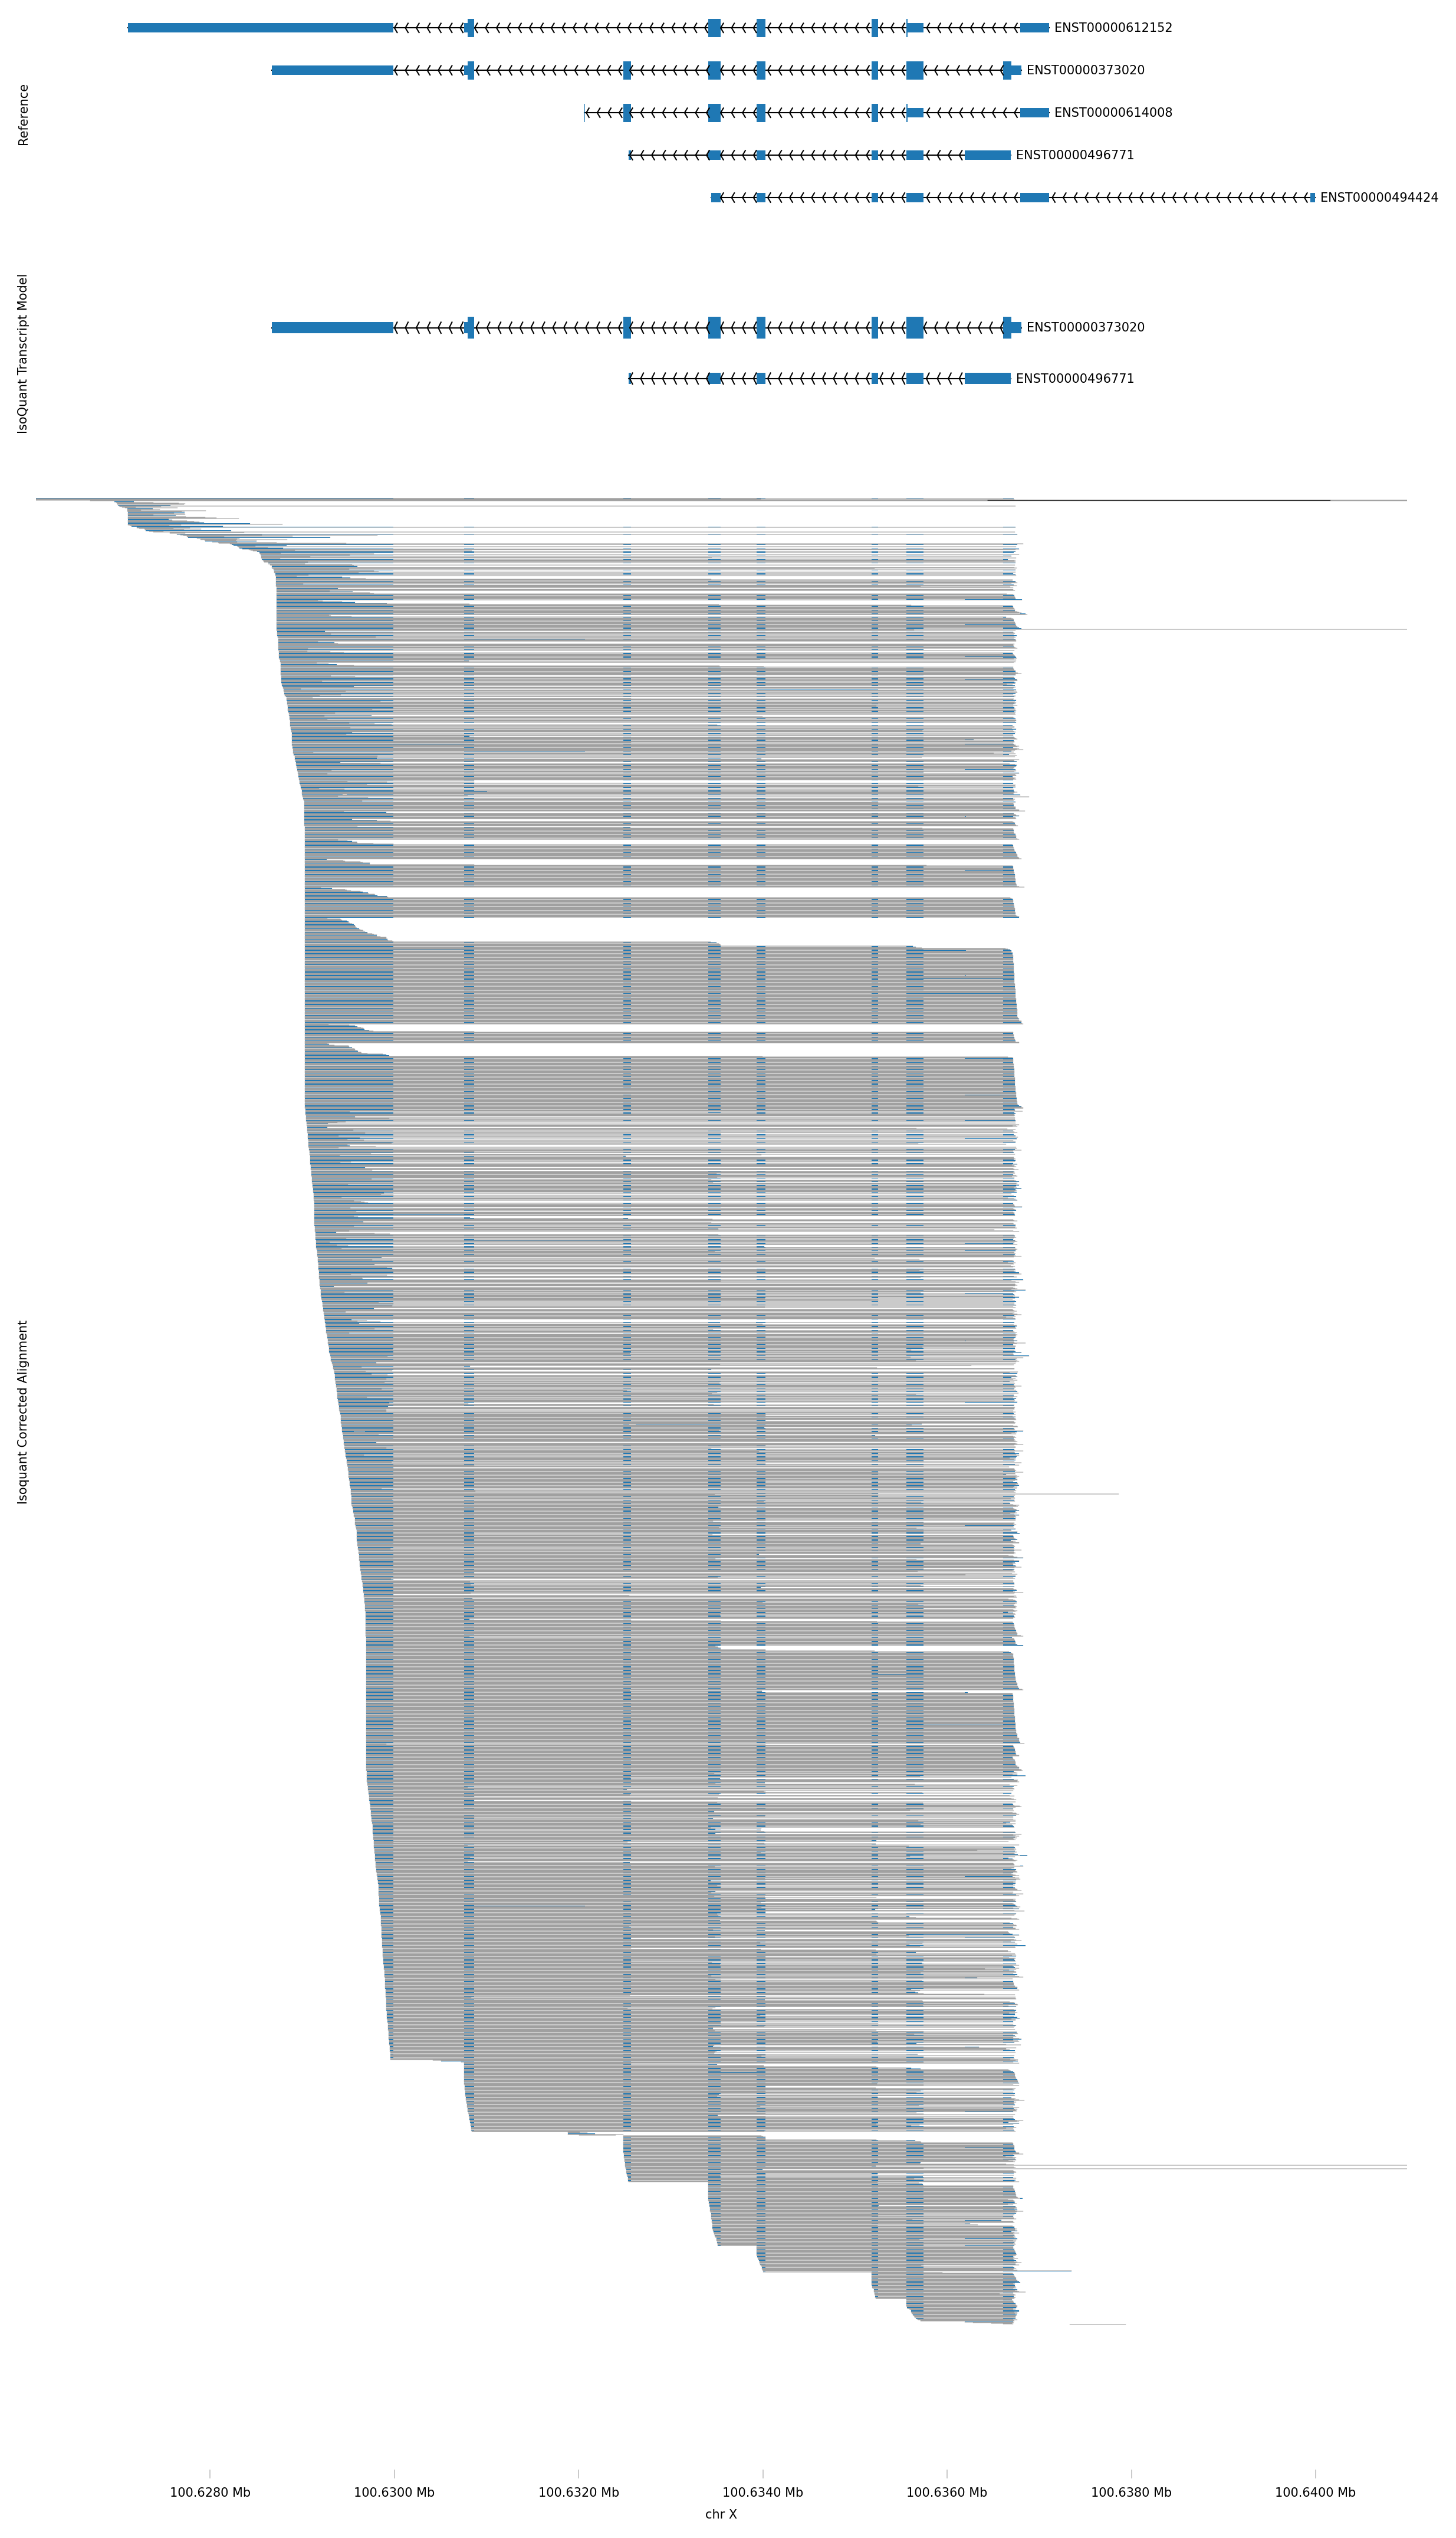

In [17]:
tracks_params = {'reads': {
                            'arrowhead_fraction':0.5
                            }}

plot_func.plot_genomic_region(output,
                            gene_name = 'TSPAN6',
                            tracks_params = tracks_params )
